## Clustering TEI documents based on XML tag branches

In this notebook we regard TEI-XML paths (e.g. `TEI.text.group.text.body.div.sp.l` rather than just `l`) as features, as carriers of the concepts the editor(s) wanted to annotated. The assumption is that TEI document let themselves be clustered according to the commensurate use of such path (documents that distinctly use the same XML paths will cluster together). The interpretation is that this tells us something about the different perspective from which the source have been edited. 

First we need to parse some TEI-XML documents into separate documents containing just all the XML-paths used in each document. 

In [78]:
from xml.parsers import expat

def branch_text_positions(xml_string):
    
    parser = expat.ParserCreate()

    results = []
    stack = []

    text_pos = 0  # position in tag-stripped text

    def to_branch( name ):
        tag_names = [ item['tag'] for item in stack ]
        tag_names.append( name )
        return '.'.join( tag_names )

    def start(name, attrs):
        nonlocal text_pos
        stack.append({
            "tag": name,
            "start": text_pos
        })

    def end(name):
        nonlocal text_pos
        item = stack.pop()
        item['tag'] = to_branch( item['tag'] )
        item['end'] = text_pos
        results.append(item)

    def char_data(data):
        nonlocal text_pos
        text_pos += len(data)

    parser.StartElementHandler = start
    parser.EndElementHandler = end
    parser.CharacterDataHandler = char_data

    parser.Parse(xml_string)

    return results

In [104]:
from glob import glob
import pandas
from random import randrange

bp_dfs = {}

# file_paths = glob( './archive/data/20260521/**/*.xml' )
file_paths = glob( './data/document_level/**/*.xml', recursive=True )

print( len( file_paths ) )
for path in file_paths:
    print( path )


226
./data/document_level/CURSUS-OnlineResourceOfMedievalLiturgicalTexts/Solomon-vulgata-reference.xml
./data/document_level/CoReMa/manuscripts/Wo8.xml
./data/document_level/CoReMa/manuscripts/Wo9.xml
./data/document_level/CoReMa/manuscripts/A1.xml
./data/document_level/CoReMa/manuscripts/M2.xml
./data/document_level/CoReMa/manuscripts/M1.xml
./data/document_level/CoReMa/manuscripts/Ha1.xml
./data/document_level/CoReMa/manuscripts/M5.xml
./data/document_level/CoReMa/manuscripts/Db1.xml
./data/document_level/CoReMa/manuscripts/St1.xml
./data/document_level/CoReMa/manuscripts/M6.xml
./data/document_level/CoReMa/manuscripts/M11.xml
./data/document_level/CoReMa/manuscripts/Pr1.xml
./data/document_level/CoReMa/manuscripts/M10.xml
./data/document_level/CoReMa/manuscripts/M7.xml
./data/document_level/CoReMa/manuscripts/K1.xml
./data/document_level/CoReMa/manuscripts/Ste1.xml
./data/document_level/CoReMa/manuscripts/Pa1.xml
./data/document_level/CoReMa/manuscripts/Ka1.xml
./data/document_level

In [105]:
file_count = 0

for file_path in file_paths:
    with open( file_path, 'r' ) as xml_file:
        try:
            xml = xml_file.read()
        except Exception as e:
            print( '')
            print( str( e ), file_path )
            with open( file_path, 'r', encoding='latin-1' ) as xml_file:
                xml = xml_file.read()
        bp = branch_text_positions( xml )
        bp_df = pandas.DataFrame( bp )
        bp_dfs[ file_path ] = bp_df
    file_count += 1
    print( file_count, end='' )
    if file_count % 30 == 0:
        print( ' ' )
    else:
        print( ', ', end='' )
        
# Quick check…
result_from_one_file = list( bp_dfs.keys() )[ randrange( len( file_paths ) ) ]
print( '\n\n', result_from_one_file, '=>' )
bp_dfs[ result_from_one_file ]


1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30 
31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60 
61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90 
91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120 
121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 
'utf-8' codec can't decode byte 0xe9 in position 1802: invalid continuation byte ./data/document_level/beckettarchive/krapp-MS-UoR-1227-7-7-1.xml
137, 138, 139, 
'utf-8' codec can't decode byte 0xbd in position 109924: invalid start byte ./data/document_level/beckettarchive/krapp-MS-HRC-SB-4-2-2.xml
140, 
'utf-8' codec can't decode byte 0xe8 in position 166: invalid continuation byte ./data/document_level/beckettarchive/kra

,tag,start,end
0,TEI.teiHeader.fileDesc.titleStmt.title,24,160
1,TEI.teiHeader.fileDesc.titleStmt,15,167
2,TEI.teiHeader.fileDesc.editionStmt.edition,183,345
3,TEI.teiHeader.fileDesc.editionStmt.editor.fore...,365,371
4,TEI.teiHeader.fileDesc.editionStmt.editor.surname,382,386
...,...,...,...
5795,TEI.text.body.ab.seg,45602,45842
5796,TEI.text.body.ab,13843,45849
5797,TEI.text.body,13843,45849
5798,TEI.text,13838,45852


 We need a TF&middot;IDF vectorizer for each individual document to weight each type of branch in each individual document. Branches (or paths) of TEI-XML tag look like `TEI.text.group.text.body.div.div.div.sp.lg.l.add` and `TEI.text.group.text.body.div.div.sp.speaker.abbr`. The latter tags provide significant distinctive information, but virtually all branches share the same first tags. Those tag basically provide no distinctive information at all. We TF&middot;IDF to represent what part of branches provide more distinctive information than others.

In [106]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas

def create_branches_vectorizer():
    return TfidfVectorizer(
        token_pattern = None,
        tokenizer = lambda s: s.split( '.' ),  # split on period
        lowercase = False                      # keep as-is
    )


In [107]:
weights_docs = {}

for path_name, bp_df in bp_dfs.items():
    vectorizer = create_branches_vectorizer()
    weights_doc = vectorizer.fit_transform( bp_df[ 'tag' ] )
    df_tfidf = pandas.DataFrame( weights_doc.toarray(), columns=vectorizer.get_feature_names_out() )
    df_combined = pandas.concat( [bp_df, df_tfidf.mean( axis=1 )], axis=1 )
    df_combined.rename( columns={0:'weight'}, inplace=True )
    sorted_by_weight = ( 
        df_combined.groupby( 'tag', as_index=False )
            .agg( mean_weight=( 'weight', 'mean' ),  # .agg( new_column_name = ( 'existing_column_name', 'function_to_apply' )
                count=( 'weight', 'count' ) )
            .sort_values( by='mean_weight', ascending=False )
            .reset_index( drop=True )
        )
    weights_docs[ path_name ] = sorted_by_weight


In [108]:
weights_docs

{'./data/document_level/CURSUS-OnlineResourceOfMedievalLiturgicalTexts/Solomon-vulgata-reference.xml':                                                   tag  mean_weight  count
 0   CURSUS.text.body.chapter.verse.reference.bookName     0.243323    116
 1   CURSUS.text.body.chapter.verse.reference.verseNum     0.243323    116
 2            CURSUS.text.body.chapter.verse.reference     0.241268    116
 3                      CURSUS.text.body.chapter.verse     0.223586    116
 4                    CURSUS.text.body.chapter.verse.l     0.221832    116
 5                            CURSUS.text.body.chapter     0.199992      8
 6          CURSUS.text.body.rubric.reference.verseNum     0.199211      2
 7          CURSUS.text.body.rubric.reference.bookName     0.199211      2
 8                           CURSUS.text.body.rubric.l     0.179901      2
 9                                    CURSUS.text.body     0.173205      1
 10                  CURSUS.text.body.rubric.reference     0.173033      

Now we have a dictionary with for each key (which is the pathname of an XML file) the weights for each branch found in that document.

Next we create a TF-IDF representing the branches in each XML document.

In [109]:
doc_vectorizer = TfidfVectorizer(
    token_pattern = None,
    tokenizer = lambda s: s.split( ' ' ),  # split on space
    lowercase = False                      # keep as-is
)

branch_docs = []

for key in weights_docs.keys():
    bp_df = bp_dfs[key]
    print( f'{len( bp_df['tag'].unique() )} unique branches in {key}' )
    branch_doc = ' '.join( bp_df['tag'].values )
    branch_docs.append( branch_doc )

tfidf_docs = doc_vectorizer.fit_transform( branch_docs )

14 unique branches in ./data/document_level/CURSUS-OnlineResourceOfMedievalLiturgicalTexts/Solomon-vulgata-reference.xml
184 unique branches in ./data/document_level/CoReMa/manuscripts/Wo8.xml
175 unique branches in ./data/document_level/CoReMa/manuscripts/Wo9.xml
232 unique branches in ./data/document_level/CoReMa/manuscripts/A1.xml
150 unique branches in ./data/document_level/CoReMa/manuscripts/M2.xml
154 unique branches in ./data/document_level/CoReMa/manuscripts/M1.xml
166 unique branches in ./data/document_level/CoReMa/manuscripts/Ha1.xml
155 unique branches in ./data/document_level/CoReMa/manuscripts/M5.xml
198 unique branches in ./data/document_level/CoReMa/manuscripts/Db1.xml
133 unique branches in ./data/document_level/CoReMa/manuscripts/St1.xml
151 unique branches in ./data/document_level/CoReMa/manuscripts/M6.xml
227 unique branches in ./data/document_level/CoReMa/manuscripts/M11.xml
175 unique branches in ./data/document_level/CoReMa/manuscripts/Pr1.xml
171 unique branches 

In [110]:
tfidf_docs.shape

(226, 2700)

Now the intricate part of combining TF-IDF and weights.

In [111]:
from scipy.sparse import lil_matrix

# Create a matrix the same size of the TF-IDF that contains all documents.
W = lil_matrix( tfidf_docs.shape )

for i, weights_doc in enumerate( weights_docs.values() ):

    # Get the weights
    branch_weights = list( zip( weights_doc['tag'], weights_doc['mean_weight'] ) )

    # Fill W with weights for each document
    for branch_weight in branch_weights:
        if branch_weight[0] in doc_vectorizer.vocabulary_:
            # find the column index of the feature ('tag') in the documents TF-IDF
            j = doc_vectorizer.vocabulary_[branch_weight[0]]
            # ut the weight on the same index in the weights matrix
            W[i, j] = branch_weight[1]


tfidf_docs_weighted = tfidf_docs.multiply( W )
print( tfidf_docs.toarray() )
print( tfidf_docs_weighted.toarray() )

[[0.0038528 0.0038528 0.0038528 ... 0.        0.        0.       ]
 [0.        0.        0.        ... 0.        0.        0.       ]
 [0.        0.        0.        ... 0.        0.        0.       ]
 ...
 [0.        0.        0.        ... 0.        0.        0.       ]
 [0.        0.        0.        ... 0.        0.        0.       ]
 [0.        0.        0.        ... 0.        0.        0.       ]]
[[0.00038528 0.00054487 0.00066732 ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]


In [112]:
from sklearn.cluster import KMeans

file_paths_clusterlabels = {}
kmeans = KMeans( n_clusters=3, random_state=0 )
labels = kmeans.fit_predict( tfidf_docs_weighted )

for i, label in enumerate( labels ):
    file_paths_clusterlabels[ file_paths[i] ] = label

df_clusters = pandas.DataFrame.from_dict( file_paths_clusterlabels, orient='index', columns=['cluster'] )
df_clusters.reset_index().rename(columns={ 'index': 'file_path' }).sort_values( by=['cluster','file_path'] )

,file_path,cluster
89,./data/document_level/Van-gogh/let002.xml,0
88,./data/document_level/Van-gogh/let003.xml,0
100,./data/document_level/Van-gogh/let004.xml,0
99,./data/document_level/Van-gogh/let005.xml,0
105,./data/document_level/Van-gogh/let006.xml,0
...,...,...
150,./data/document_level/4earlyChanTextsFromDunhu...,2
145,./data/document_level/4earlyChanTextsFromDunhu...,2
151,./data/document_level/4earlyChanTextsFromDunhu...,2
149,./data/document_level/4earlyChanTextsFromDunhu...,2


In [113]:
from sklearn.cluster import DBSCAN

db = DBSCAN( eps=0.5, min_samples=1 )
labels = db.fit_predict( tfidf_docs_weighted )

for i, label in enumerate( labels ):
    file_paths_clusterlabels[ file_paths[i] ] = label

df_clusters = pandas.DataFrame.from_dict( file_paths_clusterlabels, orient='index', columns=['cluster'] )
df_clusters.reset_index().rename(columns={ 'index': 'file_path' }).sort_values( by=['cluster','file_path'] )

,file_path,cluster
144,./data/document_level/4earlyChanTextsFromDunhu...,0
146,./data/document_level/4earlyChanTextsFromDunhu...,0
147,./data/document_level/4earlyChanTextsFromDunhu...,0
150,./data/document_level/4earlyChanTextsFromDunhu...,0
145,./data/document_level/4earlyChanTextsFromDunhu...,0
...,...,...
133,./data/document_level/leopardi(_)/infinito.xml,0
134,./data/document_level/leopardi(_)/laseradeldid...,0
132,./data/document_level/leopardi(_)/lavitasolita...,0
129,./data/document_level/leopardi(_)/lospaventono...,0


In [114]:
from sklearn.cluster import AgglomerativeClustering

clustering = AgglomerativeClustering(n_clusters=3)
labels = clustering.fit_predict( tfidf_docs_weighted.toarray() )

for i, label in enumerate( labels ):
    file_paths_clusterlabels[ file_paths[i] ] = label

df_clusters = pandas.DataFrame.from_dict( file_paths_clusterlabels, orient='index', columns=['cluster'] )
df_clusters.reset_index().rename(columns={ 'index': 'file_path' }).sort_values( by=['cluster','file_path'] )

,file_path,cluster
146,./data/document_level/4earlyChanTextsFromDunhu...,0
147,./data/document_level/4earlyChanTextsFromDunhu...,0
150,./data/document_level/4earlyChanTextsFromDunhu...,0
145,./data/document_level/4earlyChanTextsFromDunhu...,0
151,./data/document_level/4earlyChanTextsFromDunhu...,0
...,...,...
72,./data/document_level/Van-gogh/let899.xml,1
67,./data/document_level/Van-gogh/let900.xml,1
68,./data/document_level/Van-gogh/let901.xml,1
70,./data/document_level/Van-gogh/let902.xml,1


/Users/joris/Workspace/THINK/conflint/representation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


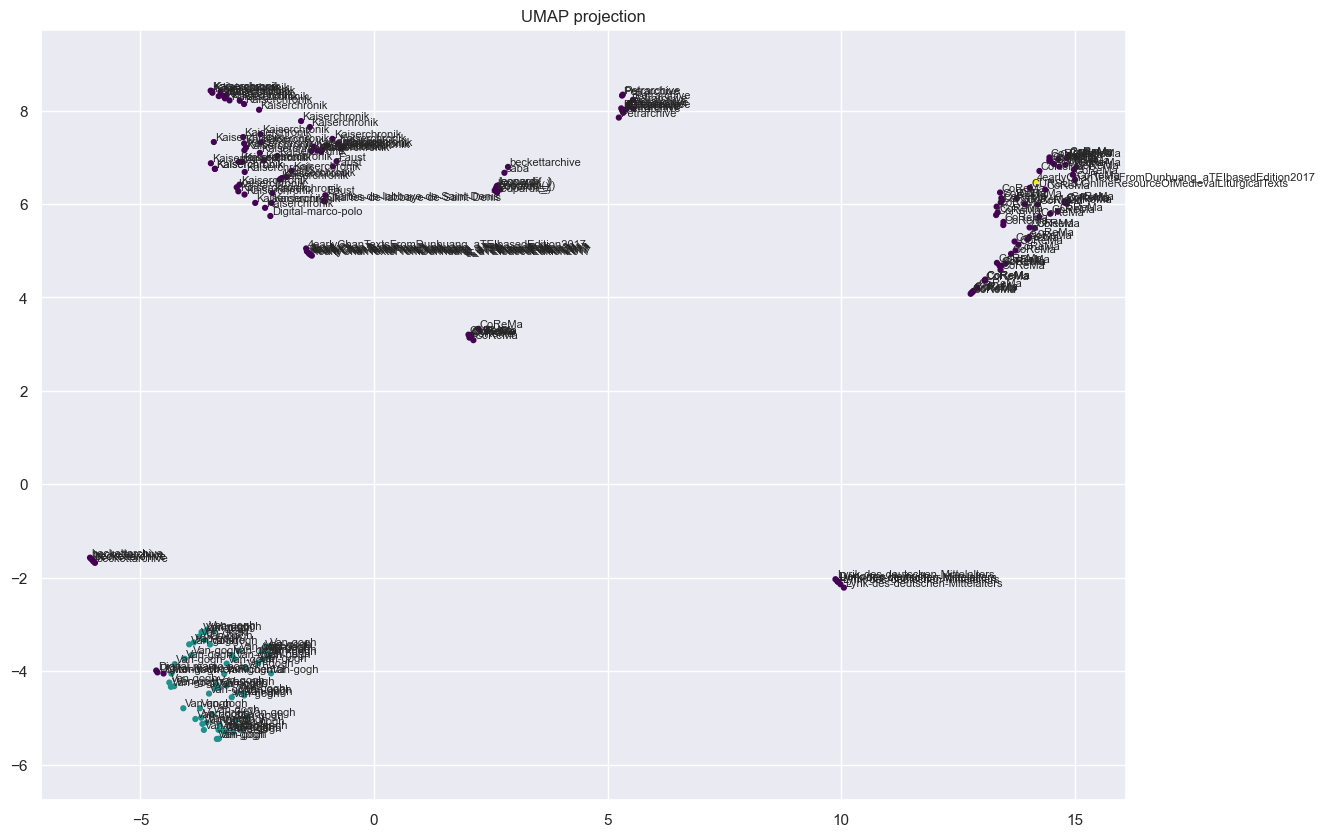

In [121]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

reducer = umap.UMAP(
    n_neighbors=10,
    n_components=2,
    metric='cosine', 
    random_state=42
)
embedding = reducer.fit_transform( tfidf_docs_weighted )

plt.figure( figsize=(14, 10) )
plt.scatter( embedding[:, 0], embedding[:, 1], c=labels, cmap='viridis', s=12 )
plt.gca().set_aspect( 'equal', 'datalim' )
plt.title( 'UMAP projection' )
offset = 0.03
for i in range( 0, len( embedding ) ):
    # We cluster individual files, but we label them at the edition level using the folder name.
    plt.text( embedding[i,0] + offset, embedding[i,1] + offset, f'{file_paths[i].split('/')[3]}', size=8, rotation=0, rotation_mode='anchor' )
    
plt.savefig( 'result_doc_level.png', dpi=300 )

plt.show()



Well, it is great to see that we indeed end up with some clusters containing different editions. \
In the next notebook we'll try to cluster at the edition level, see if that gives a clearer picture.


In [117]:
file_path.split('/')[3]

'saba'